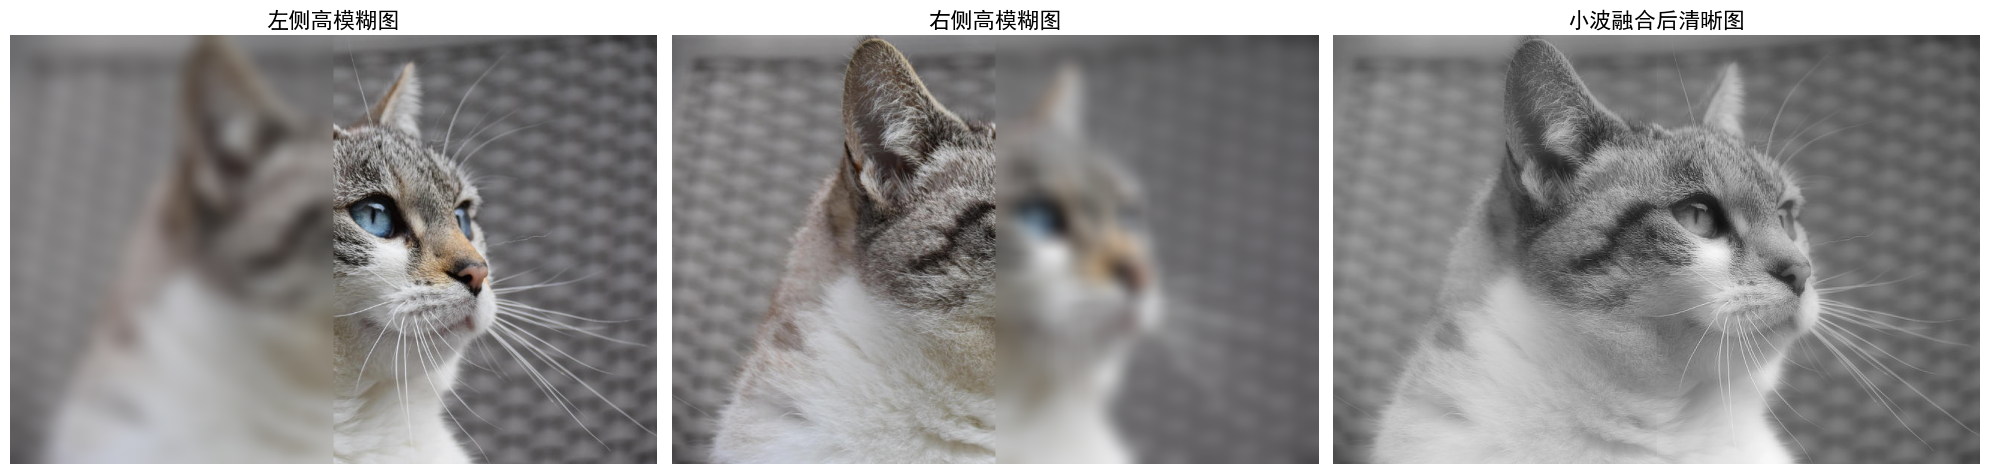

In [4]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取图像
img = cv2.imread('cat.jpg')
if img is None:
    raise ValueError("未找到cat.jpg！请确认路径正确")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
mid = w // 2

# 生成高模糊图
img1 = img.copy()
img1[:, :mid] = cv2.GaussianBlur(img1[:, :mid], (35, 35), 15)
img2 = img.copy()
img2[:, mid:] = cv2.GaussianBlur(img2[:, mid:], (35, 35), 15)

# 转灰度
gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

# 小波融合
def wavelet_fusion(im1, im2, wavelet='db2', level=1):
    coeffs1 = pywt.wavedec2(im1, wavelet=wavelet, level=level)
    coeffs2 = pywt.wavedec2(im2, wavelet=wavelet, level=level)
    fused_coeffs = []
    for c1, c2 in zip(coeffs1, coeffs2):
        if isinstance(c1, np.ndarray):
            fused = 0.5 * c1 + 0.5 * c2
            fused_coeffs.append(fused)
        else:
            fused_sub = tuple(np.where(np.abs(x) > np.abs(y), x, y) for x, y in zip(c1, c2))
            fused_coeffs.append(fused_sub)
    fused_img = pywt.waverec2(fused_coeffs, wavelet=wavelet)
    return np.clip(fused_img, 0, 255).astype(np.uint8)

# 执行融合
fused_gray = wavelet_fusion(gray1, gray2)

# 可视化
plt.figure(figsize=(20, 7))
plt.subplot(1, 3, 1)
plt.imshow(img1)
plt.title('左侧高模糊图', fontsize=16)
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(img2)
plt.title('右侧高模糊图', fontsize=16)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(fused_gray, cmap='gray')
plt.title('小波融合后清晰图', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()